# Notebook 18 - Randomness, Random Walks, and Monte Carlo Methods

## Random numbers from numpy
Really they are "pseudo-random". They approximate a truly random sequence, but they are determined by an algorithm and are completely determined by the "seed"

In [1]:
import numpy as np
r = np.random.rand()  # random float in [0.0,1)
print(r)

0.37126353715124905


In [2]:
r1 = np.random.rand()
r2 = np.random.rand()
r3 = np.random.rand()
r4 = np.random.rand()
print(r1)
print(r2)
print(r3)
print(r4)

0.8279965774565055
0.1013340662860166
0.9629951214086317
0.16196275321279596


In [3]:
# note: other functions in the random package do the same thing
# They are all an alias of random_sample
r1 = np.random.random_sample()
r2 = np.random.rand()
r3 = np.random.random()
r4 = np.random.ranf()
r5 = np.random.sample()
print(r1)
print(r2)
print(r3)
print(r4)
print(r5)

0.40185149811107124
0.3007988379598714
0.056971239986007394
0.23012981340983274
0.34895138790489666


In [4]:
# return a float between 0 and 1000
r1 = np.random.rand() * 1000
r2 = np.random.uniform(0,1000) #[low=0.0, high=1.0)  p(x)=1/(b-a)
print(r1)
print(r2)

328.7393500591651
337.4121737208586


In [5]:
r2 = np.random.uniform(-10,-5)
print(r2)

-5.594204378206021


In [6]:
r2 = np.random.randint(0,5)           # random integer in [low,high)
print(r2)

4


In [7]:
# You can also return an array filled with random numbers
r  = np.random.rand()
a1 = np.random.rand(3)  # this paramter is called "size"
a2 = np.random.rand(4,4)
print(type(r))
print(r)
print()
print(type(a1))
print(a1)
print()
print(type(a2))
print(a2)

<class 'float'>
0.1557905368987802

<class 'numpy.ndarray'>
[0.67743428 0.48944866 0.01801888]

<class 'numpy.ndarray'>
[[0.7325527  0.31296199 0.40381392 0.52593557]
 [0.36192127 0.43901877 0.43489113 0.74481977]
 [0.41611399 0.73793959 0.71322665 0.17949532]
 [0.33352835 0.39315101 0.41168423 0.3529603 ]]


In [8]:
a3 = np.random.uniform(0,1000,5)  #uniform([low, high, size])
print(a3)
print()
a3 = np.random.randint(0,1000,5) #randint(low[, high, size,)
print(a3)

[ 44.02470056 578.04851564 515.7817248  361.83450988 499.24902448]

[464 424 341 494 421]


In [9]:
# You can set to seed to have repeatable random numbers
np.random.seed(5)
print(np.random.rand())
np.random.seed(5)
print(np.random.rand())
np.random.seed()
print(np.random.rand())
np.random.seed(5)
print(np.random.rand())

0.22199317108973948
0.22199317108973948
0.2064480851100421
0.22199317108973948


In [10]:
x = [103,55,29,502]
np.random.choice(x)  # randomly select from a list or array

np.int64(502)

In [11]:
# randomly select 3 elements from a list or array and return an array
np.random.choice(x,3,replace=False)

array([502, 103,  29])

In [12]:
# replace = after you select one element, put it back before selecting the next
np.random.choice(x,3,replace=True)  # replace=True is the default

array([103,  55, 103])

## Random numbers from python's built-in library
Again these are "pseudo-random"
https://docs.python.org/3/library/random.html

In [13]:
from random import random
random() # random float in the half open interval [0.0,1)

0.7124766032184485

In [14]:
from random import uniform
uniform(1, 10)  # random float in the half open interval  [1.0,10.0)

5.981258844133442

In [15]:
from random import randrange
randrange(10) # random integer in [0,9]

3

In [16]:
randrange(0, 101, 2) # random even integer in [0,100]  -  (start, stop[, step])

34

In [17]:
from random import choice
r = ['dog', 'cat', 'horse', 'bird']
choice(r)    # randomly select a single element from a sequence

'dog'

In [18]:
from random import shuffle
shuffle(r)    # randomly shuffle a list
print(r)

['horse', 'cat', 'bird', 'dog']


In [19]:
from random import sample
sample(r, k=2) # randomly select k elements of a list and create a new list. "without replacement"

['cat', 'dog']

In [20]:
from random import SystemRandom
print(SystemRandom().choice(r))   # more secure random

horse


## Examples: Using random numbers in simulations and calculations


#### Monte Carlo Methods
* Computational techniques using random sampling
    * Monte Carlo Integration - "Throw many darts"
    * Optimization - minimize or maximize in a N dimensional space
    * Simulation
* Very wide usage in many fields
    

#### Random walk
* Simulate the path of a particle after N random steps
* Related to many real-world effects
    * Brownian motion
    * Diffusion
    * Ecology (foraging animals)
    * Economics (stock prices)


### Monte Carlo Method Examples

#### Example 1

Decay of Thallium 208 to Lead 208 with a half life $\tau$= 3.053 minutes. Simulate the number of atoms as a function of time.

The number of thallium atoms as a function of time is given by:

$N(t) = N(0)2^{-t/\tau}$

The fraction of atoms remaining is therefore

$N(T)/N(0) = 2^{-t/\tau}$

The fraction that have decayed is  $1-2^{-t/\tau}$ which is also equal to the probability that any singele atom has decayed.

Simulate the decay of 1000 atoms using random numbers. Every second we will consider each thallium atom and use the probabiliy  $p(t)=1-2^{-t/\tau}$ to determine if a decay occurs.

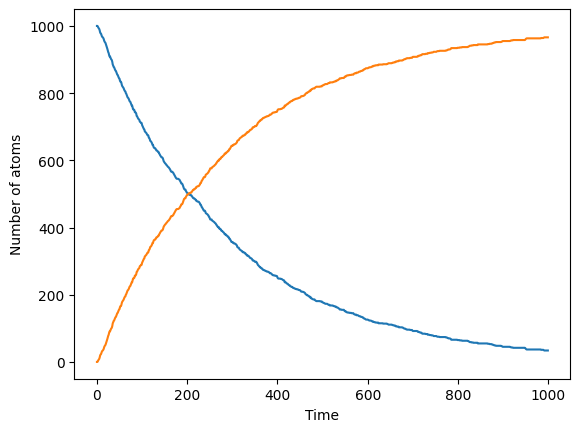

In [21]:
from random import random
from numpy import arange
from pylab import plot,xlabel,ylabel,show

# Constants
NTl = 1000            # Number of thallium atoms
NPb = 0               # Number of lead atoms
tau = 3.053*60        # Half life of thallium in seconds
h = 1.0               # Size of time-step in seconds
p = 1 - 2**(-h/tau)   # Probability of decay in one step
tmax = 1000           # Total time

# Lists of plot points
tpoints = arange(0.0,tmax,h)
Tlpoints = []
Pbpoints = []

# Main loop
for t in tpoints:
    Tlpoints.append(NTl)
    Pbpoints.append(NPb)

    # Calculate the number of atoms that decay
    decay = 0
    for i in range(NTl):
        if random()<p:
            decay += 1
    NTl -= decay
    NPb += decay

# Make the graph
plot(tpoints,Tlpoints)
plot(tpoints,Pbpoints)
xlabel("Time")
ylabel("Number of atoms")
show()


### Example 2

In many physical systems, we need to find the state with the minimum energy (the ground state). However, the energy landscape is often complex, with many "traps" (local minima) where a standard calculus-based approach (like gradient descent) would get stuck.

Instead of following the slope, we randomly sample the entire space. By checking enough random points, we statistically increase our chances of landing in the true global minimum.

In this example:
1. We define a "wavy" potential energy function $V(x) = 0.5(x-2)^2 - 2\cos(4x)$.
2. A standard ball rolling down the hill might get stuck in a local dip.
3. We use Monte Carlo sampling to pick $N$ random configurations and identify the one with the lowest energy.

Global Minimum found at x ≈ 1.600 with Energy = -1.907


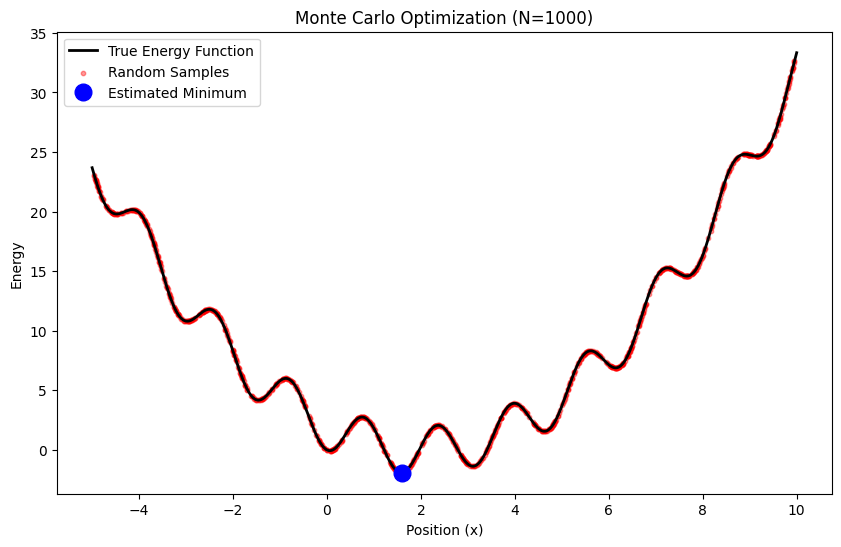

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Define a bumpy function to minimize (e.g., a potential energy )
# This function has multiple "local" minima where a standard solver might get stuck.
def potential_energy(x):
    return 0.5 * (x - 2)**2 - 2 * np.cos(4 * x)

# Monte Carlo Step: "Shoot" random samples across the domain
N_samples = 1000
x_range = (-5, 10) # Range to look for a minimum
x_guess = np.random.uniform(low=x_range[0], high=x_range[1], size=N_samples) # N random x-values within the range
y_guess = potential_energy(x_guess) # Function value at each random point

# Find the minimum energy
min_index = np.argmin(y_guess)
best_x = x_guess[min_index]
best_y = y_guess[min_index]

print(f"Global Minimum found at x ≈ {best_x:.3f} with Energy = {best_y:.3f}")

# Visualize the search
x_true = np.linspace(x_range[0], x_range[1], 1000)
y_true = potential_energy(x_true)

plt.figure(figsize=(10, 6))
plt.plot(x_true, y_true, 'k-', linewidth=2, label="True Energy Function")
plt.scatter(x_guess, y_guess, color='red', alpha=0.4, s=10, label="Random Samples")
plt.plot(best_x, best_y, 'bo', markersize=12, label="Estimated Minimum")

plt.title(f"Monte Carlo Optimization (N={N_samples})")
plt.xlabel("Position (x)")
plt.ylabel("Energy")
plt.legend()
plt.show()

### Random Walk Examples


In [23]:
# Random Walk 1
# Very basic 1D random walk (slow since it uses a for loop)
#
import numpy as np

n_steps  = 200     # Number of steps
position = 0     # Current position along the x-axis
verbose  = False  # Detailed print

if verbose:
    print("Flip details:")

for step in range(n_steps):

    # randomly pick 0 or 1
    coin = np.random.randint(0,2) # random integer in [low,high)

    # if 0(heads), move one step in the +x direction
    if coin==0:
        position+=1
        if verbose:
            print(" Heads")

    # if 1(tails), move one step  in the -x direcgtion
    if coin==1:
        position-=1
        if verbose:
            print(" Tails")

print("Final position:", position)

Final position: 8


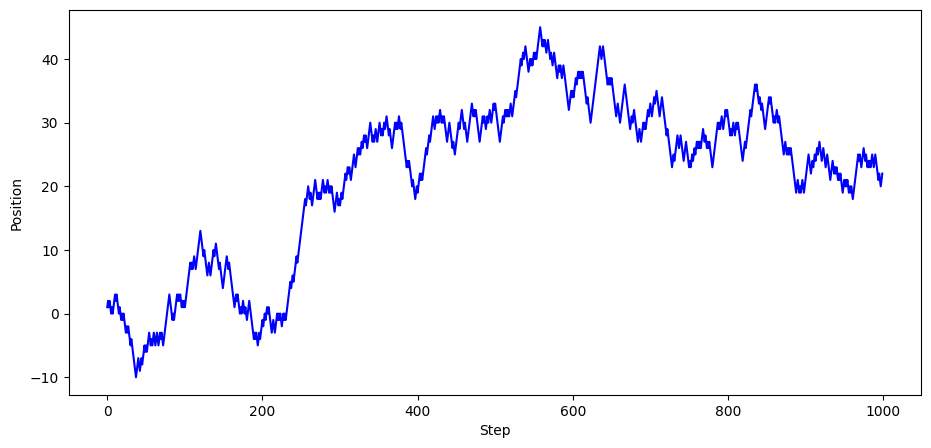

In [24]:
# Random Walk 2
# Very basic 1D random walk
# Add a plot of the position of the walker for each step (Plot the drunk person's path)
import numpy as np
import matplotlib.pyplot as plt

n_steps  = 1000     # Number of steps
position = 0     # Current position along the x-axis
verbose  = False  # Detailed print
position = 0     # Set initial position

position_tracker = np.zeros(n_steps)
step_tracker = np.zeros(n_steps)

if verbose:
    print("Flip details:")

for step in range(n_steps):

    # randomly pick 0 or 1
    coin = np.random.randint(0,2) # random integer in [low,high)

    # if 0(heads), move one step in the +x direction
    if coin==0:
        position+=1
        if verbose:
            print(" Heads")

    # if 1(tails), move one step  in the -x direcgtion
    if coin==1:
        position-=1
        if verbose:
            print(" Tails")

    # Save the position for this step in an array
    position_tracker[step] = position
    # Save the step number
    step_tracker[step]     = step

#print(step_tracker)
#print(position_tracker)
plt.rcParams['figure.figsize'] = 11, 5 # Make the plot wider (11 inches wide, 5 inches tall)
plt.plot(step_tracker,position_tracker,"b-")
plt.xlabel("Step")
plt.ylabel("Position")
plt.show()

(5, 200)


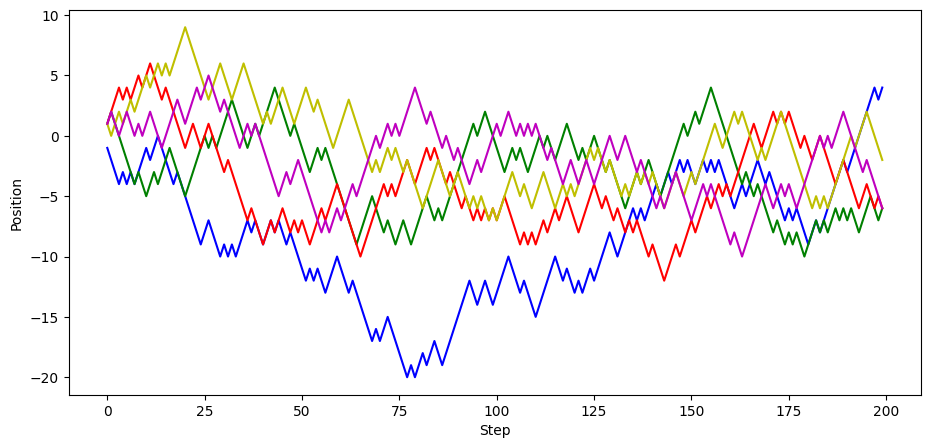

In [25]:
# Random Walk 3
# Very basic 1D random walk
# Add a loop over people so we can plot multiple drunk people's paths
import numpy as np
import matplotlib.pyplot as plt

n_people = 5      # Number of people

n_steps  = 200    # Number of steps
position = 0      # Current position along the x-axis
verbose  = False  # Detailed print

position_tracker = np.zeros(shape=(n_people,n_steps))
step_tracker     = np.zeros(n_steps)

print(position_tracker.shape)

for drunk in range(n_people):
    position = 0     # Set initial position
    for step in range(n_steps):

        # randomly pick 0 or 1
        coin = np.random.randint(0,2) # random integer in [low,high)

        # if 0(heads), move one step in the +x direction
        if coin==0:
            position+=1

        # if 1(tails), move one step  in the -x direcgtion
        if coin==1:
            position-=1

        # Save the position for this step in an array
        #print("step",step,"drunk",drunk)

        position_tracker[drunk][step] = position
        # Save the step number
        step_tracker[step]     = step

    colors = ('b', 'g', 'r','y', 'm', 'c', 'k')
    color = colors[drunk]
    plt.plot(step_tracker,position_tracker[drunk,:],"-",color=color)



plt.rcParams['figure.figsize'] = 11, 8 # Make the plot wider (11 inches wide, 5 inches tall)
plt.xlabel("Step")
plt.ylabel("Position")
plt.show()

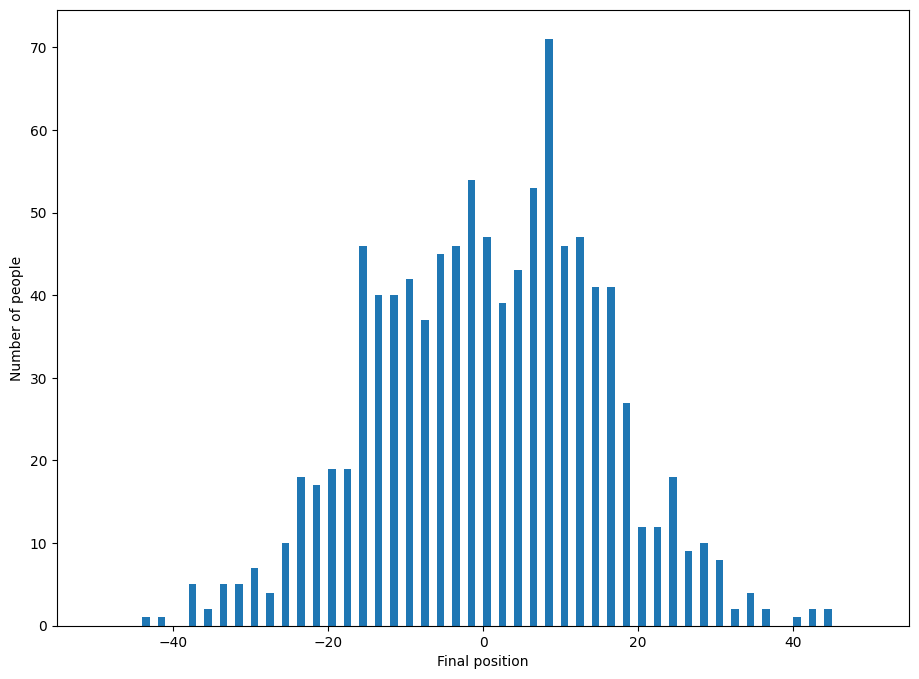

In [26]:
# Random Walk 4
# Very basic 1D random walk
# Add a plot of the final position of many drunkards
import numpy as np
import matplotlib.pyplot as plt

n_steps  = 200    # Number of steps
n_people = 1000   # Number of people

final_positions = np.zeros(n_people)
y = final_positions

for drunk in range(n_people):

    position = 0     # Set position along the x-axis to zero

    for step in range(n_steps):

        # randomly pick 0 or 1
        coin = np.random.randint(0,2) # random integer in [low,high)

        # if 0(heads), move one step in the +x direction
        if coin==0:
            position+=1

        # if 1(tails), move one step  in the -x direcgtion
        if coin==1:
            position-=1

    final_positions[drunk] = position


#plt.hist(final_positions, bins=2*n_steps,  range=(-n_steps,n_steps))#
plt.hist(final_positions, bins=100,  range=(-50,50))
plt.xlabel("Final position")
plt.ylabel("Number of people")
plt.show()


### The Central Limit Theorem for Random Walks

The histogram above shows the final positions of many walkers. As you increase the number of steps ($N$), you will notice the distribution forms a "bell curve."

This is the **Central Limit Theorem**. The sum of many independent random variables (our steps) tends toward a Gaussian Distribution, regardless of the original distribution of the individual steps.

For a 1D random walk with step size $L=1$:
* The Mean ($\mu$) approaches $0$.
* The Standard Deviation ($\sigma$) grows as $\sqrt{N}$.

$$P(x, N) = \frac{1}{\sqrt{2\pi N}} e^{-\frac{x^2}{2N}}$$

### Random Walk Connection to Diffusion

Recall the Diffusion Equation from our PDE Notebook:

$$\frac{\partial \rho}{\partial t} = D \frac{\partial^2 \rho}{\partial x^2}$$

It describes how a substance (like molecules in air or heat in a metal rod) spreads out over time from a region of high concentration to regions of low concentration. The constants are:

* $\rho(x,t)$: The density (or probability) of finding a particle at position $x$ at time $t$.
* $D$: The **Diffusion Coefficient**, which determines how fast the spreading happens.

As we saw in the previous notebook, the rate of change of density in time ($\frac{\partial \rho}{\partial t}$) is proportional to the "concavity" or curvature of the density in space ($\frac{\partial^2 \rho}{\partial x^2}$). This essentially acts as a smoothing operation—sharp peaks (high concentration) are smoothed out over time.

If we consider the initial condition of all diffusing particles starting at $x=0$ at time $t=0$ (Dirac Delta function at $x=0$), the solution to this PDE is a Gaussian distribution that spreads over time:

$$\rho(x,t) = \frac{1}{\sqrt{4\pi D t}} e^{-\frac{x^2}{4Dt}}$$

As $t$ increases:
1.  The Peak Drops: The term $\frac{1}{\sqrt{t}}$ makes the amplitude smaller.
2.  The Width Grows: The denominator in the exponent ($4Dt$) increases, making the bell curve wider.

The random walk you simulated is the "microscopic" view of diffusion.
* Discrete: A walker takes step size $\Delta x$ every time step $\Delta t$.
* Continuous: If you make the steps infinitely small and frequent, the Random Walk becomes the Diffusion Equation.

Note: If we equate the two probability formulas, we see that for a simple random walk with step size $\Delta x = 1$ and time step $\Delta t = 1$, the Diffusion Coefficient effectively becomes $D = 1/2$. This highlights how macroscopic diffusion is just the result of microscopic random steps.



### Historical Context: Einstein & Brownian Motion

The simulation you just ran is not merely a coding exercise; it is a recreation of the logic that proved the existence of atoms.

In 1827 Botanist Robert Brown observed pollen grains suspended in water under a microscope. He noticed they jittered around randomly in still water. This phenomenon became known as **Brownian Motion**, but for nearly 80 years, no one could explain why it happened.

In 1905 Albert Einstein published a paper titled *"On the Motion of Small Particles Suspended in a Stationary Liquid."*

He proposed that the visible jitter of the pollen grains was caused by invisible collisions with water molecules. Even though individual molecules are too small to see, their random impacts on the larger pollen grain would not perfectly cancel out at any given instant, causing the grain to take a "random walk."

Einstein used the mathematics of the Random Walk to predict how far a particle should travel over time. He derived the famous relationship for the Mean Squared Displacement (MSD):

$$\langle x^2 \rangle = 2Dt$$

Where $D$ is the diffusion coefficient. He then went further, deriving $D$ from physical constants (the **Stokes-Einstein Equation**):

$$D = \frac{k_B T}{6\pi \eta r}$$

* $k_B$: Boltzmann's constant
* $T$: Temperature
* $\eta$: Viscosity of the fluid
* $r$: Radius of the particle

This equation was testable. In 1908, experimentalist Jean Perrin used Einstein's formula to calculate Avogadro's number and the size of atoms from observations of water droplets. His results matched calculations from completely different fields (like gas laws), providing the first irrefutable proof that atoms and molecules are real.

In [27]:
# Quick verification: Use SymPy to show that a gaussian is a solution to the diffusion equation

import sympy
from sympy import symbols, diff, exp, sqrt, pi, simplify, Function, Eq

# Initialize pretty printing
sympy.init_printing()

# Define the symbols
x, t, D = symbols('x t D', real=True, positive=True)

# Define density rho as an undefined Function of (x, t)
rho_symbolic = Function('rho')(x, t)

print("1. The Diffusion Equation we want to solve:")
diffusion_eq = Eq(diff(rho_symbolic, t), D * diff(rho_symbolic, x, 2)) # Define the DiffEQ. diff(rho_symbolic, t) will act like a partial derivative
display(diffusion_eq)

print("\n2. The Proposed Gaussian Solution (Probability Density Function):")
rho = (1 / sqrt(4 * pi * D * t)) * exp(-x**2 / (4 * D * t)) # Define the solution
display(rho)

print("\n3. Calculating the Time Derivative (LHS):")
d_rho_dt = diff(rho, t)
display(d_rho_dt)

print("\n4. Calculating the Spatial Derivative (RHS):")
d2_rho_dx2 = diff(rho, x, 2)
rhs = D * d2_rho_dx2
display(rhs)

print("\n5. Verification: LHS - RHS = ?")
equation_check = d_rho_dt - rhs
result = simplify(equation_check)
display(result)

if result == 0:
    print("SUCCESS: The Gaussian function is an exact solution.")
else:
    print("FAILURE: The function is not a solution.")

1. The Diffusion Equation we want to solve:


                 2          
∂               ∂           
──(ρ(x, t)) = D⋅───(ρ(x, t))
∂t                2         
                ∂x          


2. The Proposed Gaussian Solution (Probability Density Function):


     2    
   -x     
   ─────  
   4⋅D⋅t  
  ℯ       
──────────
2⋅√π⋅√D⋅√t


3. Calculating the Time Derivative (LHS):


...


4. Calculating the Spatial Derivative (RHS):


              2   
            -x    
 ⎛     2 ⎞  ───── 
 ⎜    x  ⎟  4⋅D⋅t 
-⎜2 - ───⎟⋅ℯ      
 ⎝    D⋅t⎠        
──────────────────
            3/2   
   8⋅√π⋅√D⋅t      


5. Verification: LHS - RHS = ?


0

SUCCESS: The Gaussian function is an exact solution.


[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17. 18.
 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30. 31. 32. 33. 34. 35. 36.
 37. 38. 39. 40. 41. 42. 43. 44. 45. 46. 47. 48. 49. 50. 51. 52. 53. 54.
 55. 56. 57. 58. 59. 60. 61. 62. 63. 64. 65. 66. 67. 68. 69. 70. 71. 72.
 73. 74. 75. 76. 77. 78. 79. 80. 81. 82. 83. 84. 85. 86. 87. 88. 89. 90.
 91. 92. 93. 94. 95. 96. 97. 98. 99.]
[ 0.99575901  1.4615006   1.76698161  2.06291444  2.18434796  2.43169406
  2.62579207  2.74056636  3.10460561  3.30816203  3.12042048  3.29542471
  3.59425987  3.58596375  3.92607488  4.12571254  4.29982511  4.42334715
  4.3019828   4.61870112  4.60388705  4.93213301  4.76197438  4.76902506
  5.01867871  4.81805936  5.28316723  5.12359874  4.85417923  5.61779316
  5.46446704  5.50237621  5.8718297   5.84802052  6.00050531  6.04529569
  6.13998176  6.44856573  6.18410349  5.96389135  6.31273506  6.68877986
  6.23719296  6.61742065  7.08991848  6.97338827  6.82521912  7.05774582
  7.02995989 

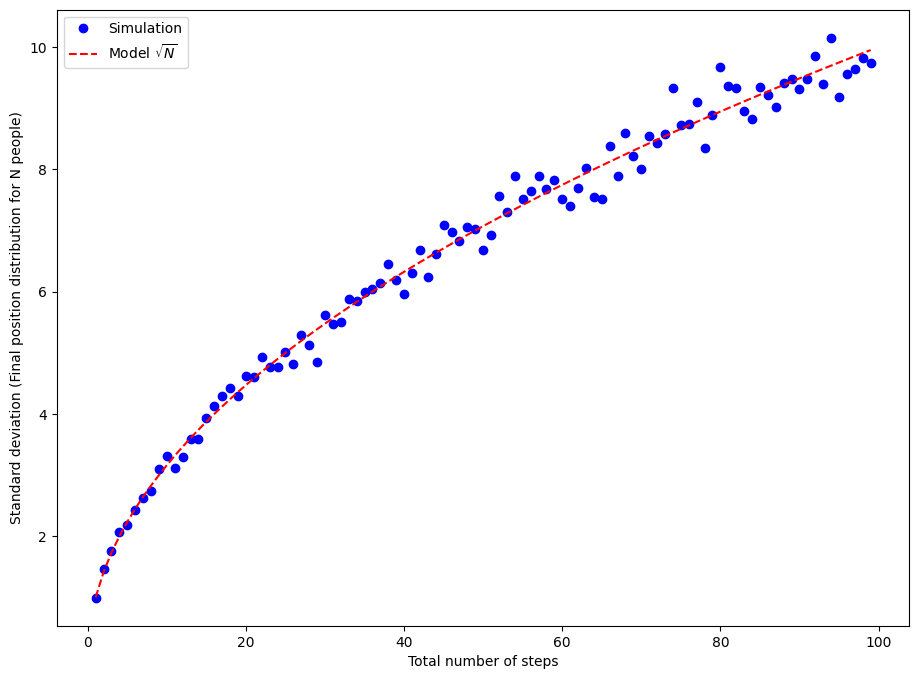

In [28]:
# Random Walk 5
# Very basic 1D random walk
# Plot standard deviation for different number of steps
import numpy as np
import matplotlib.pyplot as plt

n_steps  = 100    # Number of steps
n_people = 500   # Number of people


step_min = 1
step_max = n_steps

a_n_steps = np.zeros(step_max-step_min)
a_pos_std = np.zeros(step_max-step_min)
model     = np.zeros(step_max-step_min)


count =0
for n_steps in range(step_min,step_max):

    final_positions = np.zeros(n_people)

    for drunk in range(n_people):

        position = 0     # Set position along the x-axis to zero

        for step in range(n_steps):

            # randomly pick 0 or 1
            coin = np.random.randint(0,2) # random integer in [low,high)

            # if 0(heads), move one step in the +x direction
            if coin==0:
                position+=1

            # if 1(tails), move one step  in the -x direcgtion
            if coin==1:
                position-=1

        final_positions[drunk] = position

    final_pos_mean  = np.mean(final_positions)  # mean
    final_pos_std   = np.std(final_positions)   # standard deviation

    a_n_steps[count] = n_steps
    a_pos_std[count] = final_pos_std
    model[count]     = np.sqrt(n_steps)
    count+=1

print(a_n_steps)
print(a_pos_std)

plt.plot(a_n_steps,a_pos_std,"bo",linestyle='', label='Simulation')
plt.plot(a_n_steps,model,"r--", label='Model $\\sqrt{N}$')
plt.legend()
plt.xlabel("Total number of steps")
plt.ylabel("Standard deviation (Final position distribution for N people)")
plt.show()


Of course, we can run a random walk much faster if we use a vectorized Numpy approach:

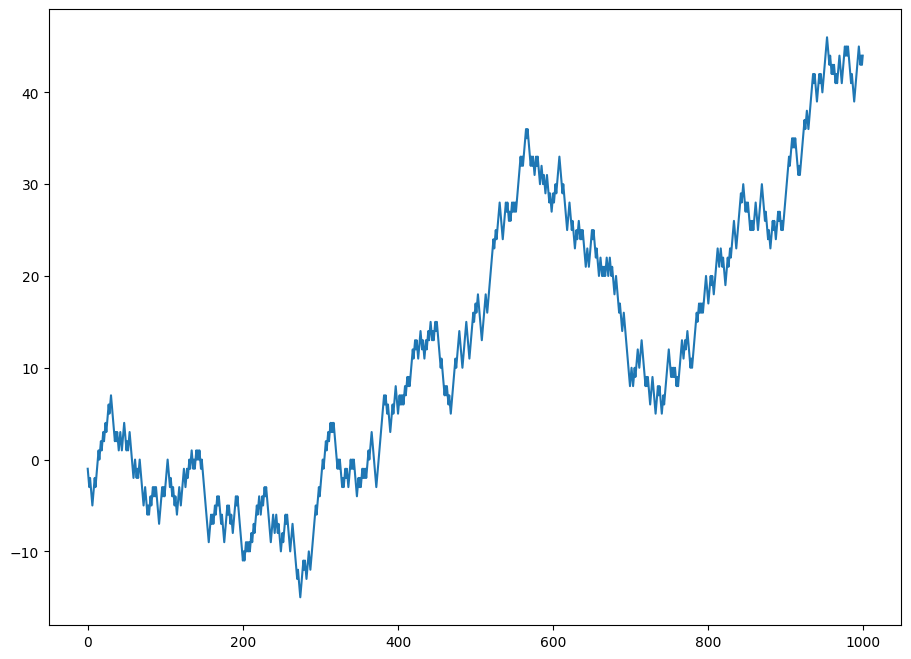

In [29]:
n_steps = 1000
# Generate 1000 random steps of -1 or +1 instantly
steps = np.random.choice([-1, 1], size=n_steps)
# Calculate position at every step using cumulative sum
path = np.cumsum(steps)

plt.plot(path)
plt.show()

### Making your own pseudo random number generator

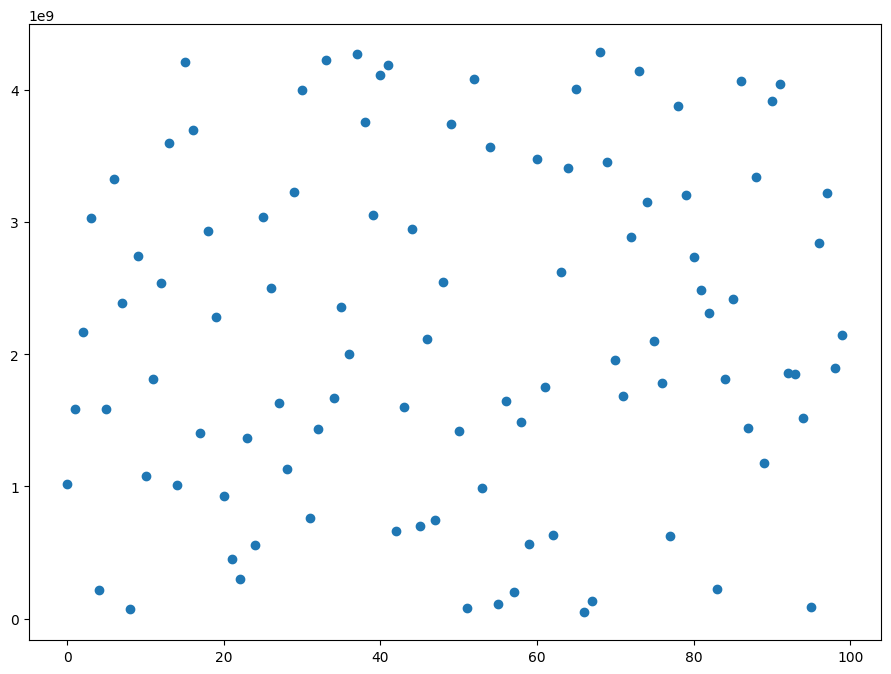

In [30]:
# Linear congruential random number generator
# Caution: This is not actually random

from pylab import plot,show

N = 100
a = 1664525
c = 1013904223
m = 4294967296
x = 1
results = []

for i in range(N):
    x = (a*x+c)%m
    results.append(x)
plot(results,"o")
show()
